# Lab 3 — Model-Free RL: Q-Learning & SARSA

**Unit:** U25 · Phase G — Reinforcement Learning (Part 1)
**Goal:** Learn an optimal policy **without** access to the MDP's transition model — purely from sampled experience.

In this lab you will:

1. Run **Q-learning** (off-policy TD control) on a grid-world.
2. Add **ε-greedy exploration**.
3. Implement **SARSA** (on-policy TD control) and compare.
4. Visualize learned $Q$-tables and policies.
5. Test on the classic **CliffWalking** environment — the textbook example of on-policy vs off-policy behavior.

> 📌 *In Lab 2 we had `env.unwrapped.P`. Here we pretend we don't — the agent must learn from rewards alone, like a real-world robot.*


## 0. Setup

In [1]:
# Install if needed (run once)
# !pip install gymnasium numpy matplotlib --quiet

# Standard imports
import numpy as np                              # numerical arrays
import matplotlib.pyplot as plt                 # plotting
import gymnasium as gym                         # RL environments
import random                                   # for ε-greedy randomness
import warnings                                 # silence noise
warnings.filterwarnings("ignore")               # cleaner output

# Set seeds for reproducibility
np.random.seed(42)                              # numpy seed
random.seed(42)                                 # python seed
print("Setup complete ✓")                       # confirmation

Setup complete ✓


## 1. The Idea: Learn $Q(s, a)$ from Experience

> *Recall from the slides:* the **Q-learning** update is
> $$Q(s,a) \leftarrow Q(s,a) + \alpha \, [\, r + \gamma \max_{a'} Q(s', a') - Q(s, a) \,]$$
>
> The bracketed term is the **TD error** — the gap between our current estimate and a better one.

We store $Q$ as a 2-D numpy array of shape `(n_states, n_actions)`.


In [2]:
# Create the same FrozenLake environment as Lab 2
env = gym.make(
    "FrozenLake-v1",                            # environment name
    map_name="4x4",                             # 4x4 grid
    is_slippery=False                           # deterministic for clarity
)

# Inspect sizes
n_states  = env.observation_space.n             # |S| = 16
n_actions = env.action_space.n                  # |A| = 4
print(f"States={n_states}, Actions={n_actions}")  # show the sizes

# Initialize the Q-table to zeros — we know nothing yet
Q = np.zeros((n_states, n_actions))             # shape (16, 4)
print(f"Q-table shape: {Q.shape}")              # confirm shape

States=16, Actions=4
Q-table shape: (16, 4)


## 2. ε-Greedy Exploration

> *Recall from the slides:* the exploration / exploitation balance.
>
> **ε-greedy:** most of the time pick the best-known action, but with probability ε take a random action to keep learning.


In [3]:
def epsilon_greedy(Q, state, epsilon, n_actions):
    """Return an action using ε-greedy selection."""
    if np.random.random() < epsilon:            # with prob ε ...
        return np.random.randint(n_actions)     # ... pick a random action
    else:                                       # otherwise ...
        return int(np.argmax(Q[state]))         # ... pick the greedy action

# Quick demo of the function
test_state = 0                                  # pretend we're in state 0
print("Greedy (ε=0):", epsilon_greedy(Q, test_state, 0.0, n_actions))
print("Random (ε=1):", epsilon_greedy(Q, test_state, 1.0, n_actions))

Greedy (ε=0): 0
Random (ε=1): 2


## 3. Q-Learning (Off-Policy TD Control)

The full algorithm:

```
For each episode:
    s ← env.reset()
    while not done:
        a ← ε-greedy(Q, s)
        s', r, done ← env.step(a)
        Q(s, a) ← Q(s, a) + α [ r + γ · max_a' Q(s', a') − Q(s, a) ]
        s ← s'
```

Note the `max` — Q-learning's target uses the **best** next action, even if the agent doesn't actually take it. That's why it's **off-policy**.


In [4]:
def q_learning(env, n_episodes=5000, alpha=0.1, gamma=0.99,
               epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.999):
    """Train Q-learning on a discrete-state environment."""
    # Init Q-table to zeros
    n_states  = env.observation_space.n         # number of states
    n_actions = env.action_space.n              # number of actions
    Q = np.zeros((n_states, n_actions))         # the Q-table

    # Track per-episode reward so we can plot the learning curve
    rewards_per_episode = []                    # list of total rewards
    epsilon = epsilon_start                     # current exploration rate

    # Train for n_episodes
    for ep in range(n_episodes):                # one episode at a time
        state, _ = env.reset()                  # fresh start
        total_reward = 0                        # accumulator
        done = False                            # episode flag

        # Step through the episode
        while not done:                         # until terminal
            # Choose action using ε-greedy
            action = epsilon_greedy(Q, state, epsilon, n_actions)

            # Take the action in the env
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated      # episode end?

            # Q-LEARNING UPDATE (off-policy: uses max over next actions)
            best_next = np.max(Q[next_state])   # max_a' Q(s', a')
            td_target = reward + gamma * best_next * (not done)     # bootstrap target
            td_error  = td_target - Q[state, action]                # the TD error
            Q[state, action] += alpha * td_error                    # update toward target

            state = next_state                  # move to next state
            total_reward += reward              # accumulate reward

        # Decay ε so we explore less over time
        epsilon = max(epsilon_end, epsilon * epsilon_decay)         # exponential decay

        # Record this episode's reward
        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode               # return final Q and the history

In [5]:
# Train Q-learning on FrozenLake
Q_learned, rewards_q = q_learning(env, n_episodes=5000)             # ~5k episodes

# Show the learned Q-table
print("Learned Q-table:")                       # header
print(Q_learned)                                # all (state, action) values

# Read off the greedy policy from the Q-table
policy = np.argmax(Q_learned, axis=1)           # best action per state
arrows = ['←', '↓', '→', '↑']                   # action symbols
policy_grid = np.array([arrows[a] for a in policy]).reshape(4, 4)   # 4x4 layout
print("\nLearned greedy policy:")              # header
print(policy_grid)                              # show arrows

Learned Q-table:
[[9.41480149e-01 9.50990050e-01 9.32065339e-01 9.41480149e-01]
 [9.41480149e-01 0.00000000e+00 4.80978604e-01 8.73274711e-01]
 [8.40735902e-01 2.44883228e-01 9.06264264e-04 1.02045906e-01]
 [7.01500935e-02 0.00000000e+00 0.00000000e+00 8.40295425e-05]
 [9.50990045e-01 9.60596010e-01 0.00000000e+00 9.41480149e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 9.80097009e-01 0.00000000e+00 4.43021252e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.60596009e-01 0.00000000e+00 9.70299000e-01 9.50990029e-01]
 [9.60595901e-01 9.80099942e-01 9.80100000e-01 0.00000000e+00]
 [9.70295186e-01 9.90000000e-01 0.00000000e+00 9.70273098e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 9.20157055e-01 9.90000000e-01 8.56767906e-01]
 [9.80099715e-01 9.89998648e-01 1.00000000e+00 9.80099128e-01]
 [0.00000000e+00 0.00000000e+00 0.0000

## 4. Plot the Learning Curve

A 100-episode **rolling average** of reward shows how the agent improves over time.


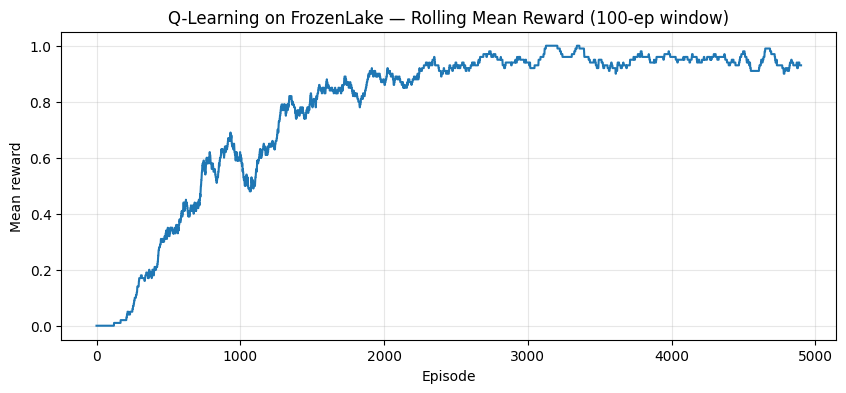

In [6]:
# Compute a rolling-mean to smooth the curve
window = 100                                    # rolling window size
rewards_arr = np.array(rewards_q)               # convert to numpy

# Compute moving average via convolution
rolling = np.convolve(rewards_arr, np.ones(window) / window, mode="valid")

# Plot it
plt.figure(figsize=(10, 4))                     # set figure size
plt.plot(rolling)                               # learning curve
plt.title("Q-Learning on FrozenLake — Rolling Mean Reward (100-ep window)")
plt.xlabel("Episode")                           # x label
plt.ylabel("Mean reward")                       # y label
plt.grid(alpha=0.3)                             # subtle grid
plt.show()                                      # render

## 5. SARSA (On-Policy TD Control)

> *Recall from the slides:* SARSA uses the action the policy **actually takes** in the next state — not the greedy max.

The update becomes:
$$Q(s,a) \leftarrow Q(s,a) + \alpha \, [\, r + \gamma \, Q(s', a') - Q(s,a) \,]$$

where $a'$ is the action chosen by the **same ε-greedy policy** the agent is following. That makes SARSA **on-policy** — and as a result, **more cautious**.


In [7]:
def sarsa(env, n_episodes=5000, alpha=0.1, gamma=0.99,
          epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.999):
    """Train SARSA on a discrete-state environment."""
    n_states  = env.observation_space.n         # number of states
    n_actions = env.action_space.n              # number of actions
    Q = np.zeros((n_states, n_actions))         # Q-table

    rewards_per_episode = []                    # log per-episode rewards
    epsilon = epsilon_start                     # initial exploration rate

    # Train for n_episodes
    for ep in range(n_episodes):                # one episode at a time
        state, _ = env.reset()                  # reset env
        # Pick the FIRST action using ε-greedy
        action = epsilon_greedy(Q, state, epsilon, n_actions)
        total_reward = 0                        # accumulator
        done = False                            # episode flag

        # Step through the episode
        while not done:                         # until terminal
            # Take the action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated      # episode end?

            # Pick the NEXT action using ε-greedy (this is the "SA" of SARSA)
            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions)

            # SARSA UPDATE (on-policy: uses the action we actually plan to take)
            td_target = reward + gamma * Q[next_state, next_action] * (not done)
            td_error  = td_target - Q[state, action]                # TD error
            Q[state, action] += alpha * td_error                    # update

            state = next_state                  # advance state
            action = next_action                # advance action (reuse next_action!)
            total_reward += reward              # accumulate reward

        # Decay ε
        epsilon = max(epsilon_end, epsilon * epsilon_decay)         # standard decay

        # Log episode reward
        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode               # final Q + history

In [ ]:
# Train SARSA on the same env
Q_sarsa, rewards_sarsa = sarsa(env, n_episodes=5000)               # train SARSA

# Print learned policy
policy_sarsa = np.argmax(Q_sarsa, axis=1)       # greedy w.r.t. learned Q
policy_grid  = np.array([arrows[a] for a in policy_sarsa]).reshape(4, 4)
print("SARSA learned policy:")                  # header
print(policy_grid)                              # show it

## 6. The Classic Test: CliffWalking

> *Recall from the slides:* "Classic illustration — the 'cliff walking' task: SARSA learns a safe path, Q-learning the optimal but riskier one."

`CliffWalking` is a 4×12 grid. Stepping off the bottom row (except start and goal) into the cliff → reward `-100` and reset. Every other step → reward `-1`.

- **Q-learning** learns the **optimal** path: right along the cliff edge (shortest path, but if exploration ever pushes us off, we get hammered).
- **SARSA** learns a **safer** path: it goes up a row first, away from the cliff, because its updates account for the fact that ε-greedy *will* occasionally pick a random action.


In [9]:
    # Make the CliffWalking environment
    cliff_env = gym.make("CliffWalking-v1")         # 4x12 grid, with a cliff

    # Train both algorithms with the SAME hyperparameters
    print("Training Q-learning on CliffWalking ...")
    Q_cliff_qlearn, rewards_cliff_q = q_learning(cliff_env, n_episodes=500, alpha=0.1)

    print("Training SARSA on CliffWalking ...")
    Q_cliff_sarsa, rewards_cliff_s = sarsa(cliff_env, n_episodes=500, alpha=0.1)
    print("Done ✓")                                 # confirmation


Training Q-learning on CliffWalking ...
Training SARSA on CliffWalking ...
Done ✓


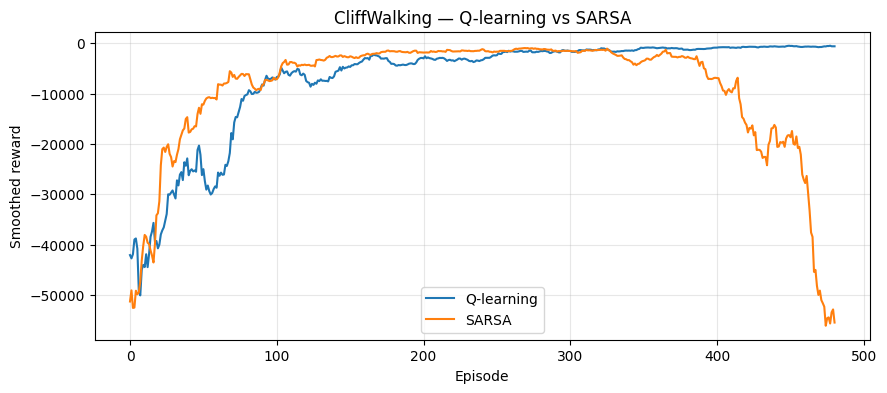

In [10]:
# Compare learning curves (rolling-mean of episode reward)
def smooth(x, w=20):                            # helper: simple rolling mean
    x = np.array(x)                             # to numpy
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(10, 4))                     # one figure
plt.plot(smooth(rewards_cliff_q), label="Q-learning")            # off-policy
plt.plot(smooth(rewards_cliff_s), label="SARSA")                 # on-policy
plt.title("CliffWalking — Q-learning vs SARSA")                 # title
plt.xlabel("Episode")                           # x label
plt.ylabel("Smoothed reward")                   # y label
plt.legend()                                    # show legend
plt.grid(alpha=0.3)                             # subtle grid
plt.show()                                      # render

**Observation:** SARSA usually finishes with **higher per-episode reward** while exploring, because it avoids the cliff. Q-learning learns the strictly-shorter path but occasionally falls off the cliff during the ε-greedy exploration, racking up −100s. This is exactly the slides' takeaway: **on-policy = safer, off-policy = optimal-but-risky-during-training**.

## 7. Visualize the Two CliffWalking Policies

Let's overlay the learned greedy policies on the grid.


In [11]:
# Extract greedy policies from both Q-tables
policy_q  = np.argmax(Q_cliff_qlearn, axis=1)   # Q-learning's greedy policy
policy_sa = np.argmax(Q_cliff_sarsa,  axis=1)   # SARSA's greedy policy

# CliffWalking action map: 0=Up, 1=Right, 2=Down, 3=Left
cliff_arrows = ['↑', '→', '↓', '←']             # arrow symbols for this env

def render_cliff(policy, title):
    """Print the CliffWalking grid annotated with the policy arrows."""
    grid = np.array([cliff_arrows[a] for a in policy]).reshape(4, 12).tolist()
    # Mark start (S), goal (G), and cliff (C)
    grid[3][0]  = 'S'                            # start cell
    grid[3][11] = 'G'                            # goal cell
    for c in range(1, 11):                       # cliff cells
        grid[3][c] = 'C'                         # mark them

    print(f"\n{title}")                         # show title
    for row in grid:                             # one row at a time
        print(" ".join(row))                     # print spaced cells

# Show both policies
render_cliff(policy_q,  "Q-learning policy (optimal but risky):")
render_cliff(policy_sa, "SARSA policy (safer, away from the cliff):")


Q-learning policy (optimal but risky):
↓ → → → → → → → → ↓ ↓ ↓
→ → → → → → → → → → → ↓
→ → → → → → → → → → → ↓
S C C C C C C C C C C G

SARSA policy (safer, away from the cliff):
← ← → ↑ ← ← ← ← → → → ↓
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ → → ↓
↑ ← ↑ ↑ ↑ ↑ ↑ ↑ ↑ → → ↓
S C C C C C C C C C C G


You should see:
- **Q-learning** marches straight along the row just above the cliff — shortest path.
- **SARSA** typically takes a higher, longer route — safer when ε-greedy might bump it sideways.


## 🎯 Recap & Homework

You built two **model-free** RL algorithms that learn purely from experience:

| Algorithm | Target uses... | Policy type | Behavior |
|---|---|---|---|
| **Q-learning** | `max_a' Q(s', a')` | Off-policy | Aggressive — chases the optimal policy |
| **SARSA**      | `Q(s', a'_actual)` | On-policy  | Conservative — accounts for its own exploration |

Both used **ε-greedy** to balance exploration vs. exploitation.

### Homework

1. Try `epsilon=0.01` vs `epsilon=0.3` (fixed, no decay). Which converges to higher reward? Which converges faster?
2. Set `alpha=0.5` — does training become more or less stable? Why?
3. Run each algorithm 5 times with different seeds and plot the **mean ± std** of the learning curve. RL is noisy!
4. Switch FrozenLake to `is_slippery=True`. Does Q-learning still converge? How many more episodes did it need?
5. Compute the **value function** $V(s) = \max_a Q(s, a)$ from each learned $Q$-table and compare to the $V^*$ you computed in Lab 2.

➡️ **Next up:** Reinforcement Learning **Part 2** — scaling these ideas with neural networks (DQN, policy gradients).
